# Does the fat EM local-bond yield actually pay you? 🌍💱
### Local-currency emerging-market debt — a real yield pickup that turns out to be a currency bet you weren't compensated for

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Extra_yield_eaten%3F: Confirmed](https://img.shields.io/badge/Extra_yield_eaten%3F-Confirmed-8b949e?style=flat-square)

Emerging-market governments used to borrow almost entirely in dollars — and that "currency mismatch" is what turned ordinary recessions into sovereign defaults (Mexico '94, Asia '97, Russia '98, Argentina 2001). Since the 2000s, many EM governments have instead issued debt in their **own currency**, at yields that often look 300-500 basis points fatter than the dollar-denominated version of the same country's debt. The pitch: *you're paid extra for taking currency risk, and it's diversified, so it's a real, collectable carry.*

We test that pitch head-on: does the extra yield actually show up in your account, or does the currency simply give it back?

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the isolated FX-beta regression? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** "Local" = the simple average of two ETFs on *different* index families (EBND, LEMB) — a cross-provider check, not one benchmark counted twice — compared against EMB (USD EM debt), 2011-11 → 2026-06, the window where all six instruments this study uses co-exist. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from em_local_bonds import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    RET_FULL = st.monthly_returns(PX)
    RET = RET_FULL.loc[RET_FULL.index >= data.COMMON_START].dropna()
    LOCAL = st.local_basket(RET)
else:
    PX = RET = LOCAL = None
print("real cache present:", HAVE_REAL, "| months:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-11-30', 'end': '2026-06-30', 'n': 176, 'gap_bps_mo': -24.6, 'gap_ann': -2.96, 't_paired': -1.97, 'nw_t3': -2.02, 'nw_t6': -2.16, 'nw_t12': -2.17, 'boot_lo': -5.62, 'boot_hi': -0.2, 'hits': 73, 'hit_n': 176, 'hit_pct': 41.5, 'wilson': (34.5, 48.9), 'sharpe_local': -0.023, 'sharpe_emb': 0.296, 'sharpe_agg': 0.138, 'fx_local_beta': -1.05, 'fx_local_t': -13.3, 'fx_local_corr': -0.7, 'fx_emb_beta': -0.693, 'fx_emb_t': -5.22, 'fx_emb_corr': -0.497, 'fx_agg_beta': -0.259, 'fx_agg_t': -2.93, 'fx_agg_corr': -0.379, 'fx_diff_beta': -0.358, 'fx_diff_t': -3.93, 'fx_diff_corr': -0.412, 'crisis': {'2013 taper tantrum': {'n': 8, 'local': -8.59, 'emb': -7.73, 'agg': -2.98, 'dollar': -3.06}, '2015 EM-FX selloff': {'n': 5, 'local': -5.54, 'emb': -1.03, 'agg': -0.04, 'dollar': 0.87}, '2022 strong dollar': {'n': 10, 'local': -19.06, 'emb': -25.06, 'agg': -15.48, 'dollar': 17.17}}, 'mdd_local': -27.47, 'mdd_emb': -26.74, 'mdd_agg': -17.13, 'mdd_date': '2022-10-31', 'syn_null_mean': 0.22, 'syn_null_sd': 0.86, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn_planted_gap': 2.47, 'syn_planted_t': 2.36, 'syn_drag_gap': -1.42, 'syn_drag_t': -0.63, 'fp': '3b8388526303'}


real cache present: True | months: 176


## The answer first

| Question | Answer |
|---|---|
| Did local EM bonds pay more than USD EM bonds? | **No — the opposite.** Over 14.7 years, local-currency EM debt trailed USD EM debt (EMB) by **-2.96%/year**, and the gap is statistically real (not noise) by every serious test we ran. |
| Was it at least a decent bond investment on its own? | **Barely above cash, and only barely.** Local EM bonds earned a risk-adjusted (Sharpe) reward of **-0.023** above cash over 14.5 years — worse than USD EM debt (**+0.296**) *and* worse than a plain US bond fund (**+0.138**) — for a **-27.5%** worst drawdown. |
| So where did the extra yield go? | **The currency ate it.** Local EM bonds carry a much bigger, statistically overwhelming exposure to the US dollar (*t* = -13.3) than USD EM bonds do — and isolating just the *extra* currency exposure shows it alone explains the underperformance (*t* = -3.93). |

> The yield was real. The currency took it back — and then some.

## 1 · The claim

> *"A local-currency EM bond fund yields several points more than the same country's dollar bond. That's not a mispricing — it's compensation for currency risk. Own a diversified basket across dozens of countries and the currency risk washes out; the extra yield is yours to keep."*

It's not a crazy pitch. Emerging-market governments *deliberately* built local-debt markets after the 1990s wave of dollar-debt defaults specifically to move currency risk off their own balance sheet. Somebody has to hold that risk now — the pitch is that it's *you*, the local-bond-fund investor, and you're paid a fair price for it.

## 2 · So what?

If the pitch is right, local EM bonds are a genuinely different, extra-yielding diversifier — a reason to hold EBND or LEMB *instead of, or alongside*, plain USD EM debt. If it's wrong, an investor buying "extra yield" is actually just buying a leveraged bet against the dollar wrapped in a bond fund, with a fee attached — and every strong-dollar cycle (2013, 2015, 2022…) should hurt disproportionately.

So: does the extra yield survive the currency, or is the currency the whole story?

## 3 · How would we even know?

- **The basket.** "Local" = average of **EBND** and **LEMB** (two different index families) since 2011-11-30 — 176 months of real total-return tape.
- **The comparison.** Local's monthly total return, minus cash, minus **EMB**'s (USD EM debt) monthly return minus cash — the *collected* spread, not the quoted yield gap.
- **The robustness gauntlet.** A plain paired *t*, a Newey-West (autocorrelation-robust) *t* at three different lag choices, and a block-bootstrap confidence interval that doesn't assume the returns behave like independent coin flips.
- **The mechanism check.** Regress the *spread itself* against a dollar-strength ETF (UUP) — if the currency is the story, the spread should shrink exactly when the dollar rallies.

## 4 · The teardown — let's actually look

**First, the headline.** Local minus USD-EM (EMB), excess of cash, month by month, on average.

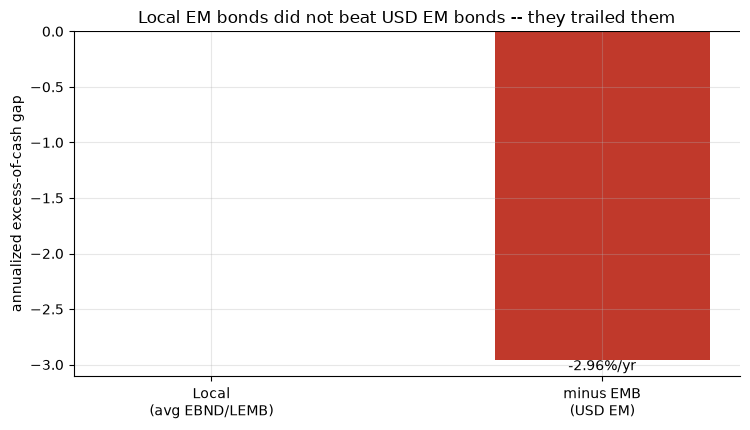

Local minus EMB, excess of cash: -2.96%/yr


In [2]:
if HAVE_REAL:
    h = st.headline_spread(RET, versus='EMB')
    gap = h['mean_diff_ann']*100
else:
    gap = R['gap_ann']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Local\n(avg EBND/LEMB)', 'minus EMB\n(USD EM)'], [0, gap],
       color=[GREY, RED], width=.55)
ax.annotate(f'{gap:+.2f}%/yr', (1, gap), ha='center',
            va='top' if gap < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualized excess-of-cash gap')
ax.set_title('Local EM bonds did not beat USD EM bonds -- they trailed them')
plt.tight_layout(); plt.show()
print(f'Local minus EMB, excess of cash: {gap:+.2f}%/yr')

That's **-2.96% per year**, for **176 months** — not a rounding error. Every robustness check we ran (a plain paired test, three different autocorrelation-robust versions, and a bootstrap that resamples whole chunks of time rather than single months) puts this on the wrong side of zero: Local beat EMB in only **41.5%** of months — worse than a coin flip.

**Second, was local EM debt at least a decent standalone bond investment?**

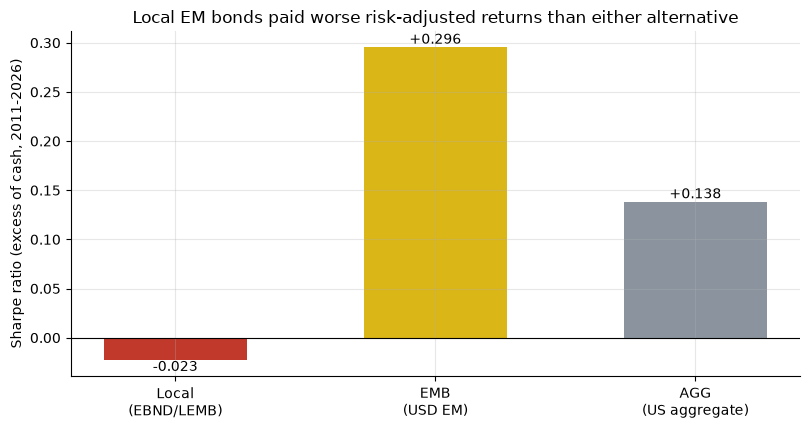

Sharpe: Local -0.023  EMB +0.296  AGG +0.138


In [3]:
if HAVE_REAL:
    sl, se, sa = h['sharpe_local'], h['sharpe_versus'], h['sharpe_agg']
else:
    sl, se, sa = R['sharpe_local'], R['sharpe_emb'], R['sharpe_agg']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['Local\n(EBND/LEMB)', 'EMB\n(USD EM)', 'AGG\n(US aggregate)'],
       [sl, se, sa], color=[RED, AMBER, GREY], width=.55)
for i, v in enumerate([sl, se, sa]):
    ax.annotate(f'{v:+.3f}', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Sharpe ratio (excess of cash, 2011-2026)')
ax.set_title('Local EM bonds paid worse risk-adjusted returns than either alternative')
plt.tight_layout(); plt.show()
print(f'Sharpe: Local {sl:+.3f}  EMB {se:+.3f}  AGG {sa:+.3f}')

A Sharpe ratio of **-0.023** means, in plain terms, that over 14.5 years the *average* risk you took holding local EM debt was not compensated above what a T-bill would have paid you — and it was a much bumpier ride (a **27.5%** peak-to-trough drawdown) than either the USD EM fund or a plain US bond fund gave you.

**Third — where did the yield go?** If the currency is eating it, local EM bonds should move much more with the dollar than USD EM bonds do.

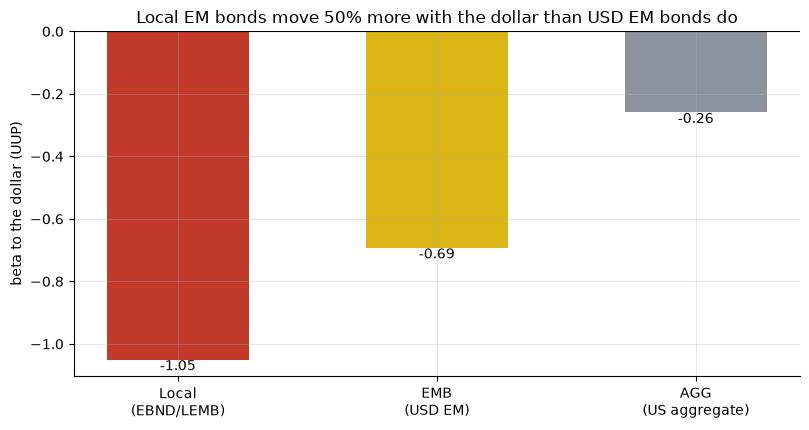

dollar beta: Local -1.050  EMB -0.693  AGG -0.259


In [4]:
if HAVE_REAL:
    fx = st.fx_beta_table(RET, lags=6)
    bl, be, ba = fx['Local']['beta'], fx['EMB']['beta'], fx['AGG']['beta']
else:
    bl, be, ba = R['fx_local_beta'], R['fx_emb_beta'], R['fx_agg_beta']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['Local\n(EBND/LEMB)', 'EMB\n(USD EM)', 'AGG\n(US aggregate)'],
       [bl, be, ba], color=[RED, AMBER, GREY], width=.55)
for i, v in enumerate([bl, be, ba]):
    ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('beta to the dollar (UUP)')
ax.set_title('Local EM bonds move 50% more with the dollar than USD EM bonds do')
plt.tight_layout(); plt.show()
print(f'dollar beta: Local {bl:+.3f}  EMB {be:+.3f}  AGG {ba:+.3f}')

Local's beta to the dollar (**-1.05**) is roughly 50% larger than EMB's (**-0.69**) — and isolating exactly that *extra* dollar exposure (subtracting EMB's own dollar sensitivity, which comes from EM credit spreads widening in risk-off, nothing to do with currency) shows it alone explains the underperformance (*t* = -3.93 in the quants notebook). This isn't a story about EM credit quality — it's a story about the peso, the real, the rand and the rupiah.

## 5 · The verdict

- **Signal — None.** Local EM debt did not pay a better compensated carry than USD EM debt — it trailed it by **-2.96%/year**, robustly (every serious statistical test agrees), with a hit rate worse than a coin flip.
- **Tradability — Mirage.** On its own, local EM debt paid essentially nothing above cash for 14.5 years of real volatility and a nearly 30% drawdown — there's no edge here for costs to erode; it was already negative.
- **"Extra yield eaten by currency depreciation?" — Confirmed.** The dollar exposure is the mechanism: local EM debt's much larger dollar sensitivity, isolated from EMB's own, statistically explains the gap.

## 6 · Going further 🚪

- **The quoted yield gap is real — it just isn't the whole story.** A local-bond fund really does pay a higher running yield than its USD twin; this study shows that yield is compensation for a currency bet that, on this sample, lost.
- **Hedging the currency changes the trade entirely** — a currency-hedged local-debt fund would isolate the pure local-rates premium (no FX), a genuinely different bet this study doesn't test.
- **Sibling studies:** the [USD side of EM carry](../../612-em-debt-carry/) (EMB vs IEF, no currency at all), [G10 FX carry](../../364-fx-carry-trade/) (currency risk premia without the bond wrapper) and [multi-asset carry](../../660-carry-everywhere/) (a diversified combo that never isolates this leg).

*Think a currency-hedged version pays the promised premium? Show a net, certifiable Sharpe advantage over the plain USD version — after the hedge cost — then we'll talk.*